In [1]:
from attention_predict.reconstruct import reconstruct_traces
import matplotlib.pyplot as plt
import numpy as np
import json
import seaborn as sns

### reconstruct traces using UNet

In [3]:
from attention_predict.unet import UNet

In [22]:
depth = 5
prj_directory = "/home/alicia/notebook/alicia/attention_predict"
ds_name = 'AVA_MC_all_test'
exp = 'exp_2024100101'
ckpt = 90

# AVA: 0, MC: 1, velocity: 2, head angle: 3, pumping: 4
# or AVA: 0, MC: 1, velocity: 2, pumping: 3
mask_indices = [1, 2]

device = 'cuda:2'
model_ckpt_path = f'/store1/alicia/attention_predict/{exp}/checkpoints/model_ckpt{ckpt}.pt'
in_channels = np.load(f'{prj_directory}/data/{ds_name}.npy').shape[1]
out_channels = in_channels
unet_dim = 1

max_length = 1600
batch_size = 1
window_size = 400
window_stride = 1
dataset_path = f'{prj_directory}/data/{ds_name}.npy'

model = UNet(
        depth, in_channels, out_channels, unet_dim=unet_dim
).to(device)
model_type = 'unet'

reconstructed_traces = reconstruct_traces(
        dataset_path,
        model,
        model_ckpt_path,
        max_length,
        model_type,
        window_size,
        window_stride,
        mask_indices=mask_indices,
        device=device)

13211it [00:02, 4633.31it/s]


 All frames added to worm0: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm1: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm2: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm3: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm4: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm5: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm6: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm7: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm8: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm9: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]

 All frames added to worm10: [(0, 399), (400, 799), (800, 1199), (1200, 1599)]


### reconstruct traces using the attention model

In [21]:
prj_directory = "/home/alicia/notebook/alicia/attention_predict"
dataset_path = f"{prj_directory}/data/AVA_MC_train.npy"
device = "cuda:2"
window_size = 50
batch_size = 1
embedding_dims = 1024
num_layers = 4
max_length = 1600
ckpt = 10000
model_ckpt_path = f"{prj_directory}/experiments/exp_2024091701/checkpoints/model_ckpt{ckpt}.pt"

reconstructed_traces = reconstruct_trace(
        dataset_path,
        model_ckpt_path,
        window_size,
        batch_size,
        embedding_dims,
        num_layers,
        max_length,
        device)

NameError: name 'reconstruct_trace' is not defined

In [ ]:
#worm_idx = 1
#var_idx = 4
#window_idx = 0

#x = np.concatenate(reconstructed_traces[worm_idx]['prediction'], axis=2).squeeze(0)
#print(x[var_idx, :])

#reconstructed_traces[worm_idx]['prediction'][window_idx].squeeze(0)[var_idx, :]

### plot reconstructed traces

In [6]:
def plot_traces(worm_idx, reconstructed_traces, xrange):

    concatenated_prediction = np.concatenate(reconstructed_traces[worm_idx]['prediction'], axis=2)
    concatenated_ground_truth = np.concatenate(reconstructed_traces[worm_idx]['ground_truth'], axis=2)
    
    prediction = concatenated_prediction.squeeze(0)
    ground_truth = concatenated_ground_truth.squeeze(0)
    
    fig, axs = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
    variables = {0: 'AVA', 1: 'MC', 2: 'velocity', 3: 'head angle', 4: 'pumping'}
    
    for i in range(5):
        axs[i].plot(prediction[i][:xrange], label='prediction')
        axs[i].plot(ground_truth[i][:xrange], label='ground truth', alpha=0.8)
        axs[i].set_title(variables[i])
        axs[i].grid(True)
        axs[i].legend()

    return prediction, ground_truth

def plot_attention(worm_idx, window_idx, reconstructed_traces):
    
    sns.heatmap(
        reconstructed_traces[worm_idx]['attention'][window_idx].squeeze(0)[:, :],
        annot=True,
        cmap='coolwarm',
        xticklabels=['AVA', 'MC', 'velocity', 'head angle', 'pumping'],
        yticklabels=['AVA', 'MC', 'velocity', 'head angle', 'pumping'],
    )

def plot_ground_truth(worm_idx, reconstructed_traces, xrange):

    concatenated_ground_truth = np.concatenate(reconstructed_traces[worm_idx]['ground_truth'], axis=2)
    ground_truth = concatenated_ground_truth.squeeze(0)
    
    fig, axs = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
    variables = {0: 'AVA', 1: 'MC', 2: 'velocity', 3: 'head angle', 4: 'pumping'}
    
    for i in range(5):
        axs[i].plot(ground_truth[i][:xrange], label='ground truth', color='#ff7f0e')
        axs[i].set_title(variables[i])
        axs[i].grid(True)
        axs[i].legend()

def plot_reconstruction(worm_idx, reconstructed_traces, xrange, model_type='attention'):

    concatenated_prediction = np.concatenate(reconstructed_traces[worm_idx]['prediction'], axis=2)    
    prediction = concatenated_prediction.squeeze(0)

    fig, axs = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
    variables = {0: 'AVA', 1: 'MC', 2: 'velocity', 3: 'head angle', 4: 'pumping'}
    
    for i in range(5):
        axs[i].plot(prediction[i][:xrange], label='prediction')
        axs[i].set_title(variables[i])
        axs[i].grid(True)
        axs[i].legend()

def plot_mse_loss(worm_idx, reconstructed_traces):

    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.plot(reconstructed_traces[worm_idx]['mse'])
    ax.set_ylabel('loss')


def plot_masked_traces(worm_idx, reconstructed_traces, xrange):

    num_inputs = len(list(reconstructed_traces[0].keys()))
    masked_outcomes = {mask_index: {} for mask_index in range(num_inputs)}
    
    for mask_index in range(num_inputs):
        concatenated_prediction = np.concatenate(
            reconstructed_traces[worm_idx][mask_index]['prediction'],
            axis=2)
        concatenated_ground_truth = np.concatenate(
            reconstructed_traces[worm_idx][mask_index]['ground_truth'],
            axis=2)
    
        prediction = concatenated_prediction.squeeze(0)
        ground_truth = concatenated_ground_truth.squeeze(0)

        masked_outcomes[mask_index]['prediction'] = prediction
        masked_outcomes[mask_index]['ground_truth'] = ground_truth
        masked_outcomes[mask_index]['mse'] = np.sum(reconstructed_traces[worm_idx][mask_index]['mse'])
    
    fig, axs = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
    variables = {0: 'AVA', 1: 'MC', 2: 'velocity', 3: 'head angle', 4: 'pumping'}
    
    for mask_index in range(num_inputs):
        axs[mask_index].plot(
            masked_outcomes[mask_index]['prediction'][mask_index, :xrange],
            label='prediction'
        )
        axs[mask_index].plot(
            masked_outcomes[mask_index]['ground_truth'][mask_index, :xrange],
            label='ground_truth',
            alpha=0.8
        )
        axs[mask_index].set_title(f'{variables[mask_index]}: MSE = {round(masked_outcomes[mask_index]['mse'], 4)}')
        axs[mask_index].grid(True)
        axs[mask_index].legend()

    return masked_outcomes

def plot_masked_multiple_traces(worm_idx, mask_indices, reconstructed_traces, xrange):

    masked_outcomes = {}
    
    mask_index = 0
    concatenated_prediction = np.concatenate(
        reconstructed_traces[worm_idx][mask_index]['prediction'],
        axis=2)
    concatenated_ground_truth = np.concatenate(
        reconstructed_traces[worm_idx][mask_index]['ground_truth'],
        axis=2)
    
    prediction = concatenated_prediction.squeeze(0)
    ground_truth = concatenated_ground_truth.squeeze(0)

    masked_outcomes['prediction'] = prediction
    masked_outcomes['ground_truth'] = ground_truth
    # summing MSE of reconstructing 4 segments (given window size = 4)
    masked_outcomes['mse'] = np.sum(reconstructed_traces[worm_idx][mask_index]['mse'])
    
    variables = {0: 'AVA', 1: 'MC', 2: 'velocity', 3: 'pumping'}
    #variables = {0: 'MC', 1: 'pumping'}
    num_variables = len(variables)
    
    fig, axs = plt.subplots(num_variables, 1, figsize=(10, 10), sharex=True)
    
    for i in range(num_variables):
        axs[i].plot(prediction[i][:xrange], label='prediction')
        axs[i].plot(ground_truth[i][:xrange], label='ground truth', alpha=0.8)
        axs[i].set_title(
            variables[i])
        axs[i].grid(True)
        axs[i].legend()

    return masked_outcomes

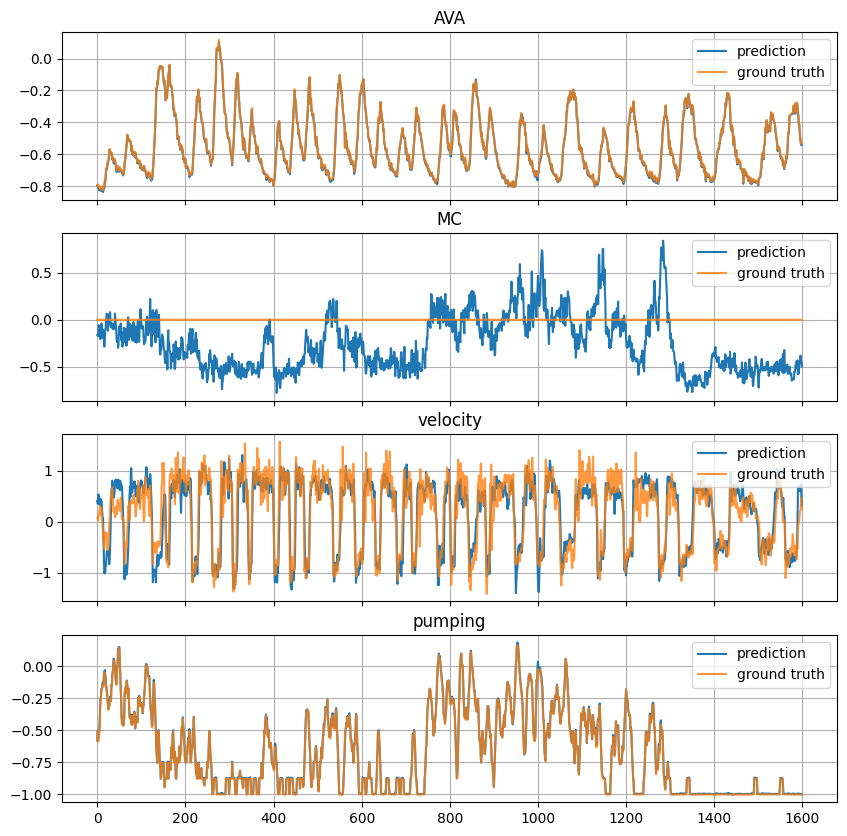

In [34]:
worm_idx = 10
mask_indices = [1, 2]
masked_outcomes = plot_masked_multiple_traces(worm_idx, mask_indices, reconstructed_traces, xrange=1600)

In [13]:
#plot_ground_truth(worm_idx, reconstructed_traces, xrange=1600)

In [ ]:
#plot_reconstruction(worm_idx, reconstructed_traces, xrange=1600)

In [14]:
#worm_idx = 2
#plot_mse_loss(worm_idx, reconstructed_traces)

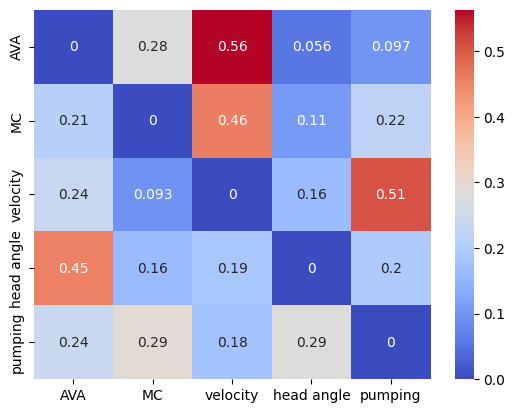

In [51]:
worm_idx = 3
window_idx = 10

plot_attention(worm_idx, window_idx, reconstructed_traces)

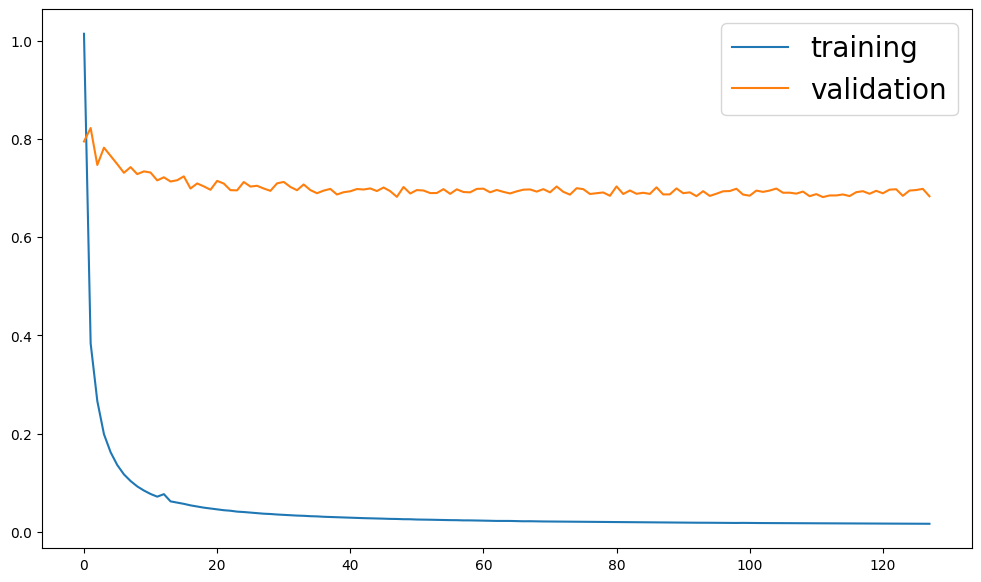

In [39]:
experiment = '/store1/alicia/attention_predict/exp_2024100101'

with open(f'{experiment}/losses.json', 'r') as f:
    loss_dict = json.load(f)

fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.plot(loss_dict['training'][:1000], label="training")
ax.plot(loss_dict['validation'][:1000], label="validation")
#ax.set_ylim(0.001, 0.035)
ax.legend(fontsize=20);

In [3]:
epoch = 67
iter = 399
experiment = "exp_20240915"
outputs = np.load(f'{experiment}/train/outputs_epoch{epoch}_iter{iter}.npy')
inputs = np.load(f'{experiment}/train/inputs_epoch{epoch}_iter{iter}.npy')
attention = np.load(f'{experiment}/train/attention_epoch{epoch}_iter{iter}.npy')

In [4]:
outputs.shape, inputs.shape, attention.shape

# AVA
# MC
# velocity
# head angle
# pumping

((32, 5, 50), (32, 5, 50), (32, 5, 5))

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

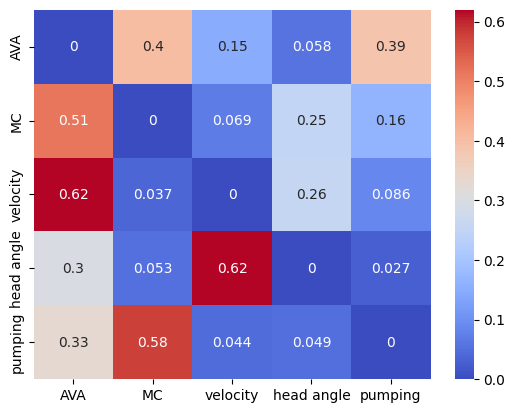

In [18]:
sample_idx = 24
sns.heatmap(
    attention[sample_idx, :, :],
    annot=True,
    cmap='coolwarm',
    xticklabels=['AVA', 'MC', 'velocity', 'head angle', 'pumping'],
    yticklabels=['AVA', 'MC', 'velocity', 'head angle', 'pumping'],
)

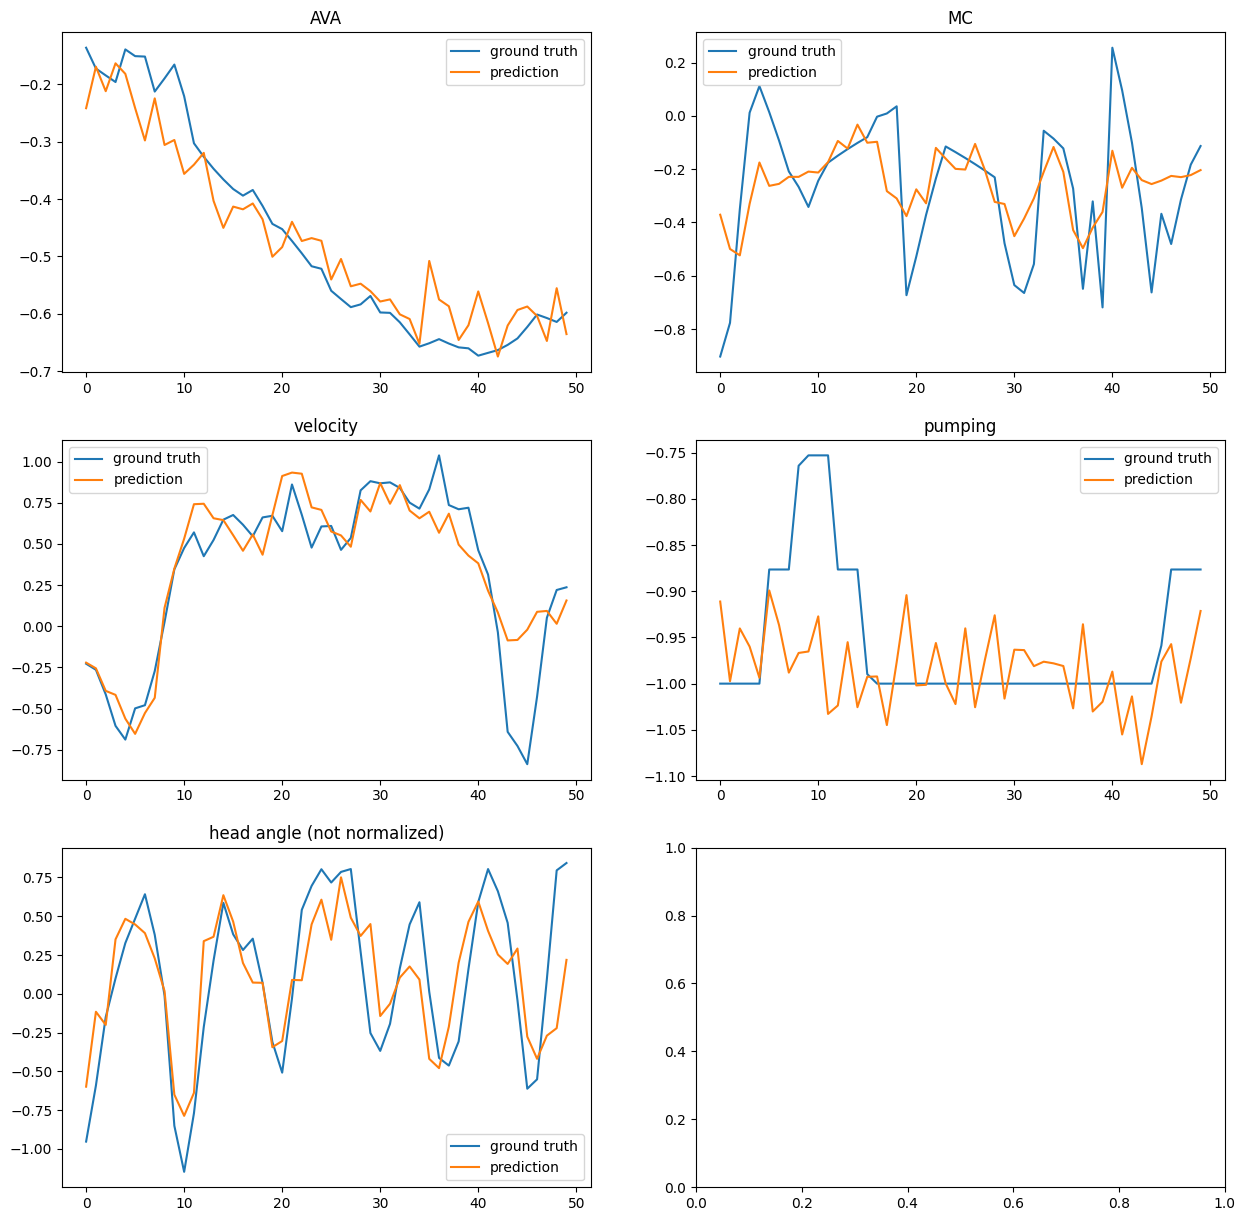

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

axes[0, 0].plot(inputs[sample_idx, 0, :], label='ground truth');
axes[0, 0].plot(outputs[sample_idx, 0, :], label='prediction');
axes[0, 0].set_title('AVA');
axes[0, 0].legend();

axes[0, 1].plot(inputs[sample_idx, 1, :], label='ground truth');
axes[0, 1].plot(outputs[sample_idx, 1, :], label='prediction');
axes[0, 1].set_title('MC');
axes[0, 1].legend();

axes[1, 0].plot(inputs[sample_idx, 2, :], label='ground truth');
axes[1, 0].plot(outputs[sample_idx, 2, :], label='prediction');
axes[1, 0].set_title('velocity');
axes[1, 0].legend();

axes[1, 1].plot(inputs[sample_idx, 4, :], label='ground truth');
axes[1, 1].plot(outputs[sample_idx, 4, :], label='prediction');
axes[1, 1].set_title('pumping');
axes[1, 1].legend();


axes[2, 0].plot(inputs[sample_idx, 3, :], label='ground truth');
axes[2, 0].plot(outputs[sample_idx, 3, :], label='prediction');
axes[2, 0].set_title('head angle (not normalized)');
axes[2, 0].legend();